In [338]:
import pandas as pd
import numpy as np 
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import joblib


In [339]:
pwd

'C:\\Users\\Aditya P. Shelar\\Desktop\\ML'

In [340]:
os.chdir('C:\\Users\\Aditya P. Shelar\\Desktop\\ML')
df=pd.read_csv('ai4i2020.csv')
display(df)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [341]:
print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [342]:
print(df.duplicated().sum())
print(df['Machine failure'].value_counts(normalize=True))

0
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


In [343]:
df.drop(['TWF',	'HDF',	'PWF',	'OSF',  'RNF'], axis=1, inplace=True)
display(df)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0


In [344]:
n=df[[
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]]
print(n)
print(n.shape)

     Type  Air temperature [K]  Process temperature [K]  \
0       M                298.1                    308.6   
1       L                298.2                    308.7   
2       L                298.1                    308.5   
3       L                298.2                    308.6   
4       L                298.2                    308.7   
...   ...                  ...                      ...   
9995    M                298.8                    308.4   
9996    H                298.9                    308.4   
9997    M                299.0                    308.6   
9998    H                299.0                    308.7   
9999    M                299.0                    308.7   

      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
0                       1551         42.8                0  
1                       1408         46.3                3  
2                       1498         49.4                5  
3                       1433         39.5      

In [345]:
m=df["Machine failure"]
print(m)

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: Machine failure, Length: 10000, dtype: int64


In [346]:
print("Class balance:", m.value_counts(normalize=True).round(4).to_dict())  # ~3.4% failures

Class balance: {0: 0.9661, 1: 0.0339}


(array([9661.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         339.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

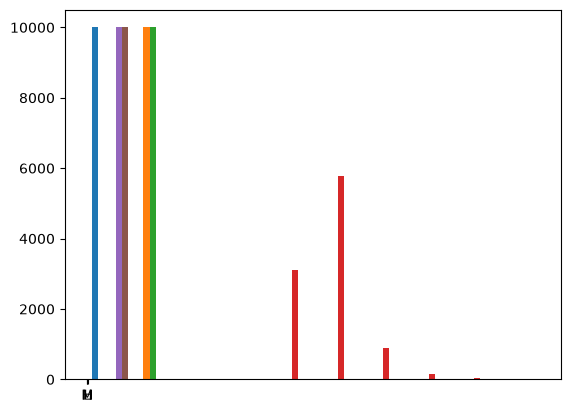

In [347]:

plt.hist(n)
plt.hist(m)

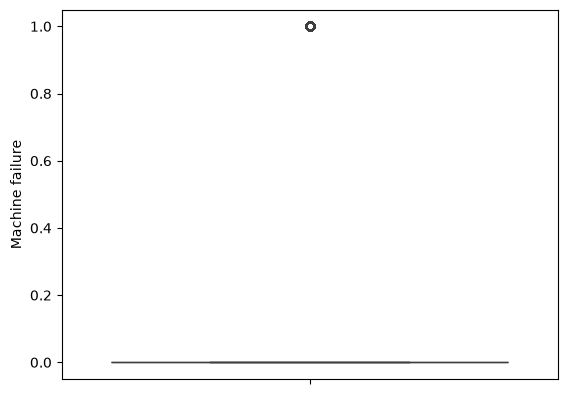

In [348]:
import matplotlib.pyplot as plt
df=sns.boxplot(m)

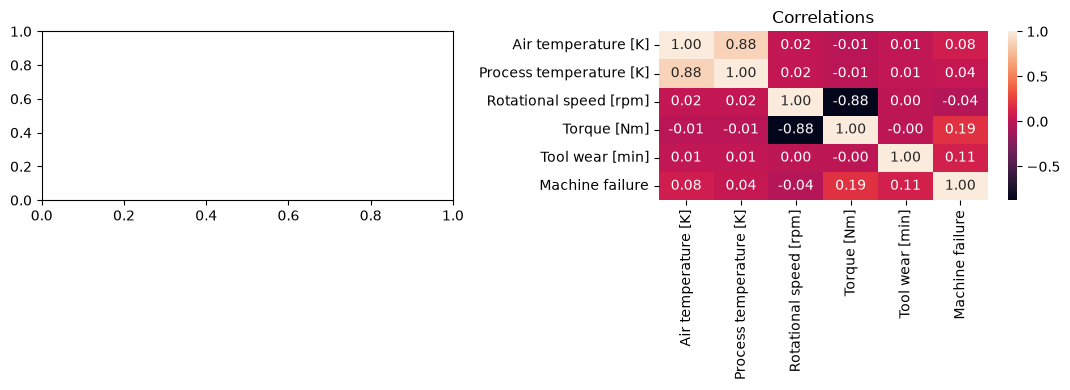

In [349]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(pd.concat([n.select_dtypes("number"), m], axis=1).corr(),
            annot=True, fmt=".2f", ax=ax[1]).set_title("Correlations")
plt.tight_layout(); plt.show()

In [350]:
sns.countplot(n=m, ax=ax[0]).set_title("Class balance")

Text(0.5, 1.0, 'Class balance')

In [351]:
from sklearn.model_selection import train_test_split
n_train,n_test,m_train,m_test=train_test_split(n,m,test_size=0.2,stratify=m,random_state=42)
print("n train model:-")
print(n_train.shape)
print("m train model:-")
print(m_train.shape)
print("n test model:-")
print(n_test.shape)
print("m test model:-")
print(m_test.shape)

n train model:-
(8000, 6)
m train model:-
(8000,)
n test model:-
(2000, 6)
m test model:-
(2000,)


In [352]:

ct = ColumnTransformer([
    ('num', StandardScaler(),[ 
        "Air temperature [K]", "Process temperature [K]",
        "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"
    ]),
    ('cat', OneHotEncoder(drop='first'),["Type"],)
])
model = Pipeline([
    ("ct", ct),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])


model.fit(n_train,m_train)
m_pred = model.predict(n_test)
print(confusion_matrix(m_test, m_pred))
cr=classification_report(m_test, m_pred, zero_division=0)
print(cr)

os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/model.pkl")

[[1928    4]
 [  61    7]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



['models/model.pkl']

In [353]:
dtc = DecisionTreeClassifier (criterion = 'entropy')
n_train = pd.get_dummies(n_train, columns=['Type'], drop_first=True)
n_test = pd.get_dummies(n_test, columns=['Type'], drop_first=True)

# make sure both have identical columns, in identical order
n_test = n_test.reindex(columns=n_train.columns, fill_value=0)

dtc.fit (n_train,m_train)
print (dtc)

DecisionTreeClassifier(criterion='entropy')


In [354]:
os.makedirs(r"C:\Users\Aditya P. Shelar\Desktop\ML\models", exist_ok=True)
joblib.dump(dtc, r"C:\Users\Aditya P. Shelar\Desktop\ML\models\model.pkl")
print(os.path.exists(r"C:\Users\Aditya P. Shelar\Desktop\ML\models\model.pkl"))

True


In [355]:
m_pred=dtc.predict(n_test)
print(m_pred)

[0 0 0 ... 0 0 0]


In [356]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(m_test,m_pred)
print(cm)

[[1908   24]
 [  26   42]]


In [357]:
from sklearn.metrics import classification_report
print(classification_report(m_test,m_pred,zero_division=0))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.64      0.62      0.63        68

    accuracy                           0.97      2000
   macro avg       0.81      0.80      0.81      2000
weighted avg       0.97      0.97      0.97      2000



In [358]:
import os
import joblib

os.makedirs(r"C:\Users\Aditya P. Shelar\Desktop\ML\models", exist_ok=True)
joblib.dump(dtc, r"C:\Users\Aditya P. Shelar\Desktop\ML\models\model.pkl")

print(os.path.exists(r"C:\Users\Aditya P. Shelar\Desktop\ML\models\model.pkl"))  # must print True

True


In [359]:
import joblib
model = joblib.load((r"C:\Users\Aditya P. Shelar\Desktop\ML\models\model.pkl"))

In [360]:
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/model.pkl")
print(model.n_features_in_, list(model.feature_names_in_))  # sanity check

7 ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']
